In [2]:
from dotenv import load_dotenv
load_dotenv 

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [3]:
import os 
import langchain


In [4]:
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")


In [5]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile")

In [6]:
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000022C2EDFCC90>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000022C2FF44B10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [11]:
from langchain_tavily import TavilySearch

tavily_search_tool= TavilySearch(
    max_result=5,
    topic="general"
)

# tool.invoke("what is the current iran vs usa war")

In [9]:
from langchain.tools import tool
@tool("calculator", description="Performs arithmetic calculations. Use this for any math problems.")
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))

In [10]:
calc

StructuredTool(name='calculator', description='Performs arithmetic calculations. Use this for any math problems.', args_schema=<class 'langchain_core.utils.pydantic.calculator'>, func=<function calc at 0x0000022C304D4720>)

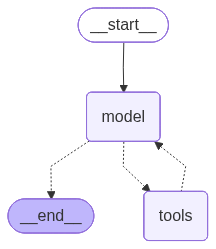

In [13]:
from langchain.agents import create_agent

agent = create_agent(
    model=llm,
    tools=[tavily_search_tool, calc],
)

agent

In [ ]:
user_input="what is the current AI news for anthropic and then caluclate 7*7*8*9*6"

for step in agent.stream(
    {"messages": user_input},
    stream_mode="messages"
):
    step["messages"][-1].pretty_print()
    # printing each step like how AI is thinking though process and each step

21168{"query": "anthropic AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://finance.yahoo.com/news/anthropic-launches-new-enterprise-offerings-raising-the-heat-on-software-companies-143054933.html", "title": "Anthropic launches new enterprise offerings, raising the heat on ...", "content": "Anthropic CEO Dario Amodei at the Code with Claude developer conference on May 22, 2025, in San Francisco. (Don Feria/AP Content Services for Anthropic) · ASSOCIATED PRESS\n\n \n\nAnthropic's moves aren't just rocking software companies. On Feb. 20, the AI firm announced Claude Code Security, which it said \"scans codebases for security vulnerabilities and suggests targeted software patches for human review.\"\n\nStory Continues\n\nThe news sent cybersecurity stocks lower, with CrowdStrike (CRWD) and Zscaler (ZS) falling 7.2% and 7.1%, respectively, as of Monday's close. Palo Alto Networks (PANW), meanwhile, dropped 2.6%.\n\nBut predictions that AI com

In [23]:
from langchain_core.messages import AIMessageChunk

for chunk, metadata in agent.stream(
    {"messages": user_input},
    stream_mode="messages"
):
    if isinstance(chunk, AIMessageChunk) and chunk.content:
        print(chunk.content, end="", flush=True)

The current AI news for Anthropic includes a leak of its unreleased 'Mythos' AI model, which has sparked cybersecurity concerns. Additionally, Anthropic's CEO, Dario Amodei, has refused to back down to the Pentagon, leading to a surge in interest in the company. The result of the calculation 7*7*8*9*6 is 21168.